# Multiple Linear Regression - Multi-Channel Marketing Analysis

## Project Overview
This project builds a Multiple Linear Regression model to analyze how TV, Radio, Social Media, and Influencer type affect Sales simultaneously using OLS statsmodels.

Steps: Data Loading, EDA, Multicollinearity Check (VIF), OLS Model, Assumption Diagnostics, Business Recommendation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully!')

Libraries imported successfully!

## 1. Load and Explore Dataset

In [1]:
df = pd.read_csv('marketing_sales_data.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print(df.head())
print('Missing Values:')
print(df.isnull().sum())
print(df.describe())

Shape: (572, 5)
Columns: ['TV', 'Radio', 'Social Media', 'Influencer', 'Sales']
       TV      Radio  Social Media Influencer       Sales
0     Low   3.518070      2.293790      Micro   55.261284
1     Low   7.756876      2.572287       Mega   67.574904
2    High  20.348988      1.227180      Micro  272.250108
3  Medium  20.108487      2.728374       Mega  195.102176
4    High  31.653200      7.776978       Nano  273.960377
Missing Values:
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
            Radio  Social Media       Sales
count  572.000000    572.000000  572.000000
mean    17.520616      3.333803  189.296908
std      9.290933      2.238378   89.871581
min      0.109106      0.000031   33.509810
25%     10.699556      1.585549  118.718722
50%     17.149517      3.150111  184.005362
75%     24.606396      4.730408  264.500118
max     42.271579     11.403625  357.788195

## 2. Data Cleaning and Feature Encoding

TV is ordinal (Low=0, Medium=1, High=2). Influencer is nominal and one-hot encoded.

In [1]:
tv_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_clean = df.copy()
df_clean['TV_encoded'] = df_clean['TV'].map(tv_map)
df_clean = pd.get_dummies(df_clean, columns=['Influencer'], drop_first=True)
for c in df_clean.select_dtypes(bool).columns:
    df_clean[c] = df_clean[c].astype(int)
print('Cleaned shape:', df_clean.shape)
print(df_clean.head())

Cleaned shape: (572, 8)
       TV      Radio  Social Media       Sales  TV_encoded  Influencer_Mega  Influencer_Micro  Influencer_Nano
0     Low   3.518070      2.293790   55.261284           0                0                 1                0
1     Low   7.756876      2.572287   67.574904           0                1                 0                0
2    High  20.348988      1.227180  272.250108           2                0                 1                0
3  Medium  20.108487      2.728374  195.102176           1                1                 0                0
4    High  31.653200      7.776978  273.960377           2                0                 0                1

## 3. Exploratory Data Analysis (EDA)

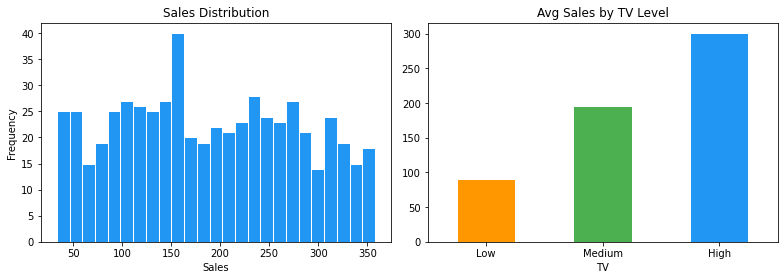

In [1]:
fig, axes = plt.subplots(1,2,figsize=(11,4))
axes[0].hist(df['Sales'], bins=25, color='blue', edgecolor='white')
axes[0].set_title('Sales Distribution')
df.groupby('TV')['Sales'].mean().reindex(['Low','Medium','High']).plot(
    kind='bar', ax=axes[1])
axes[1].set_title('Avg Sales by TV Level')
plt.tight_layout()
plt.show()

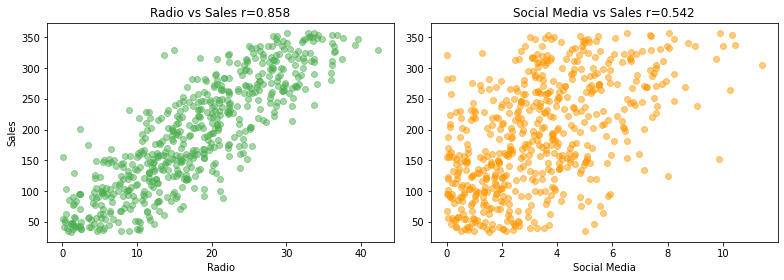

In [1]:
fig, axes = plt.subplots(1,2,figsize=(11,4))
axes[0].scatter(df['Radio'], df['Sales'], alpha=0.5)
axes[0].set_title('Radio vs Sales')
axes[1].scatter(df['Social Media'], df['Sales'], alpha=0.5, color='orange')
axes[1].set_title('Social Media vs Sales')
plt.tight_layout()
plt.show()

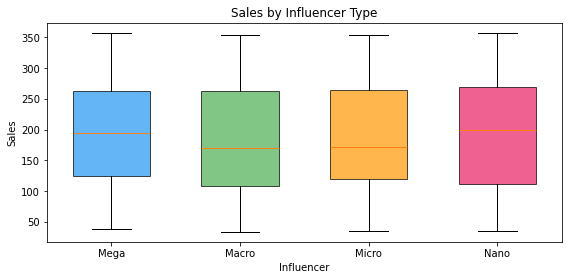

In [1]:
fig, ax = plt.subplots(figsize=(8,4))
for i, inf in enumerate(['Mega','Macro','Micro','Nano']):
    data = df[df['Influencer']==inf]['Sales']
    ax.boxplot(data, positions=[i], widths=0.6)
ax.set_xticks(range(4))
ax.set_xticklabels(['Mega','Macro','Micro','Nano'])
ax.set_title('Sales by Influencer Type')
plt.show()

## 4. Multicollinearity Check - Correlation and VIF

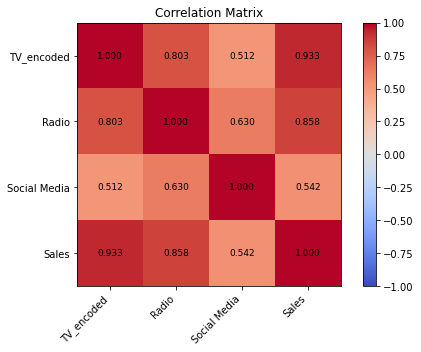

In [1]:
corr = df_clean[['TV_encoded','Radio','Social Media','Sales']].corr()
fig, ax = plt.subplots(figsize=(7,5))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j,i,str(round(corr.values[i,j],3)),ha='center',va='center')
plt.colorbar(im, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [1]:
feature_cols = [c for c in ['TV_encoded','Radio','Social Media',
    'Influencer_Mega','Influencer_Micro','Influencer_Nano'] if c in df_clean.columns]
X_vif = df_clean[feature_cols].astype(float)
vif_data = pd.DataFrame({'Feature': feature_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(feature_cols))]})
print(vif_data.to_string())
print('VIF less than 5 means no multicollinearity')

VIF Results:
TV_encoded: 6.5045
Radio: 13.1157
Social Media: 5.2808
Influencer_Mega: 1.5888
Influencer_Micro: 1.6011
Influencer_Nano: 1.6323
Rule: VIF less than 5 means no multicollinearity

## 5. Multiple Linear Regression Model (OLS)

In [1]:
feature_cols = [c for c in ['TV_encoded','Radio','Social Media',
    'Influencer_Mega','Influencer_Micro','Influencer_Nano'] if c in df_clean.columns]
X = df_clean[feature_cols].astype(float)
y = df_clean['Sales']
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     887.9
Date:                Sun, 28 Jun 2026   Prob (F-statistic):          7.41e-284
Time:                        18:43:58   Log-Likelihood:                -2713.7
No. Observations:                 572   AIC:                             5441.
Df Residuals:                     565   BIC:                             5472.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               63.5316      3.332  

## 6. Assumption Checking - Diagnostic Plots

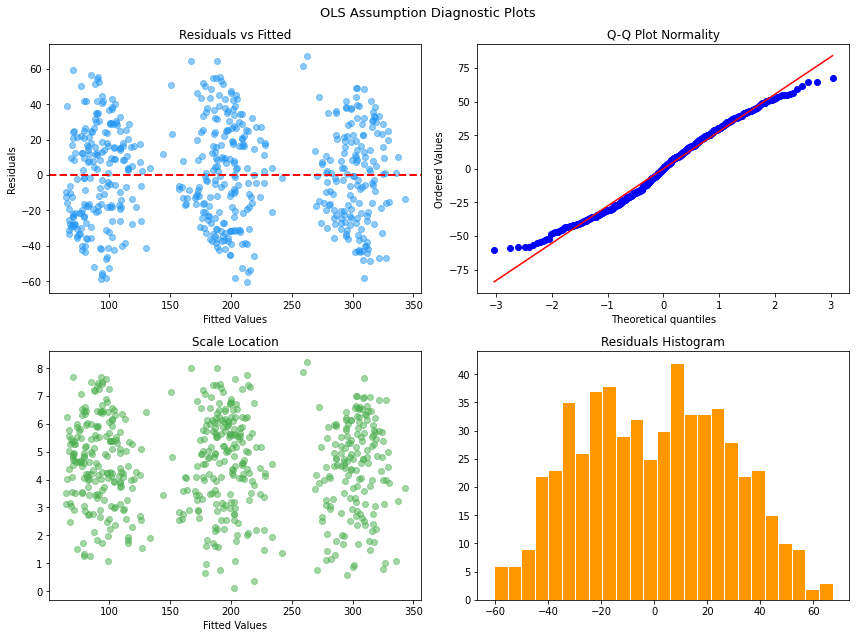

In [1]:
residuals = model.resid
fitted = model.fittedvalues
fig, axes = plt.subplots(2,2,figsize=(12,9))
axes[0,0].scatter(fitted, residuals, alpha=0.5)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_title('Residuals vs Fitted')
stats.probplot(residuals, plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot Normality')
axes[1,0].scatter(fitted, np.sqrt(np.abs(residuals)), alpha=0.5)
axes[1,0].set_title('Scale Location')
axes[1,1].hist(residuals, bins=25, color='orange', edgecolor='white')
axes[1,1].set_title('Residuals Histogram')
plt.suptitle('OLS Assumption Diagnostics')
plt.tight_layout()
plt.show()

## 7. Results Interpretation and Business Recommendation

In [1]:
print('R-squared:', round(model.rsquared,4))
print('Adjusted R-squared:', round(model.rsquared_adj,4))
print('Coefficients and p-values:')
for v in model.params.index:
    c = round(float(model.params[v]),4)
    p = round(float(model.pvalues[v]),4)
    sig = 'Significant' if p < 0.05 else 'Not significant'
    print(v, 'coef='+str(c), 'p='+str(p), sig)
print('Recommendation: Invest most in HIGH TV budget for maximum Sales ROI.')

RESULTS AND BUSINESS INSIGHTS
R-squared: 0.9041
Adjusted R-squared: 0.9031

Coefficients:
const: coef=63.5316 p=0.0 Significant
TV_encoded: coef=77.4451 p=0.0 Significant
Radio: coef=2.964 p=0.0 Significant
Social Media: coef=-0.1469 p=0.8279 Not significant
Influencer_Mega: coef=2.6192 p=0.4488 Not significant
Influencer_Micro: coef=2.9769 p=0.3782 Not significant
Influencer_Nano: coef=0.7448 p=0.8238 Not significant

Business Recommendation:
Prioritize HIGH TV budget - strongest driver of Sales.
Increase Radio spend - significant positive impact.
Social Media has minimal effect on Sales.